# UrsoNet Spacecraft Attitude Estimation
### Based on Proença & Gao (2020) — Orientation Soft Classification
### CloudSat LEO · TF 2.10 · GTX 1660

> **Core change from v1/v2:** Direct quaternion regression → **Gaussian-binned Euler angle soft classification**
> This is the architecture used by UrsoNet to achieve 3rd place in the ESA Pose Estimation Challenge.

---
## Why Soft Classification Works Better Than Quaternion Regression

| Problem with quaternion regression | How soft classification fixes it |
|---|---|
| `q ≡ −q` antipodal ambiguity | Euler angles have no antipodal seam |
| Geodesic loss has infinite gradient near convergence | CCE is smooth everywhere |
| 4D unit-sphere constraint hard for networks to learn | 3 independent softmax — no constraint needed |
| 121° plateau = model outputs mean quaternion | CCE forces differentiated bin predictions |

---
## Cell 1 — GPU Setup (MUST be first cell)

In [1]:
import tensorflow as tf
import sys, os

# Enable GPU memory growth — must run before any other TF op
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print(f"TensorFlow : {tf.__version__}")
print(f"Python     : {sys.version.split()[0]}")
print(f"GPUs       : {tf.config.list_physical_devices('GPU')}")
print(f"CUDA built : {tf.test.is_built_with_cuda()}")

TensorFlow : 2.10.1
Python     : 3.10.20
GPUs       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CUDA built : True


---
## Cell 2 — Imports & Configuration

In [2]:
import os, sys, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

sys.path.insert(0, "..")   # adjust path to where .py file lives

from resnet50_spacecraft_attitude_tf import (
    # Constants
    N_BINS, BIN_CENTERS_DEG, SIGMA_DEG,
    # GPU
    configure_gpu,
    # Utilities
    quat_to_euler_deg, euler_deg_to_quat,
    gaussian_soft_label, bins_to_quaternion,
    angular_error_deg_np, precompute_soft_labels,
    # Data pipeline
    build_dataset_urso,
    # Model
    build_ursonet,
    # Loss
    OrientationSoftClassLoss,
    # Metrics
    UrsoAngularErrorDeg, UrsoAccWithinNDeg,
    # Callbacks
    build_callbacks,
    # Optimizers
    build_optimizer, unfreeze_backbone,
    # Inference
    predict_single_image, batch_evaluate,
)

configure_gpu()

# ── Project paths ────────────────────────────────────────────
DATASET_ROOT   = "../spacecraft_dataset"
CHECKPOINT_DIR = "../checkpoints"
TRAIN_CSV      = os.path.join(DATASET_ROOT, "train.csv")
TEST_CSV       = os.path.join(DATASET_ROOT, "test.csv")
IMAGE_DIR      = os.path.join(DATASET_ROOT, "images")

# ── Hyperparameters ──────────────────────────────────────────
IMG_SIZE        = 224     # GTX 1660: 224 safe for batch 8 at full fine-tune
BATCH_SIZE      = 8       # OOM-safe for ResNet50V2 unfrozen on 6GB
WARMUP_EPOCHS   = 30      # Phase 1: head only, frozen backbone
FINETUNE_EPOCHS = 120     # Phase 2: full fine-tune (ES stops early if converged)
HEAD_LR         = 1e-3    # UrsoNet default (higher than regression due to CCE)
BACKBONE_LR     = 1e-4    # Phase 2 backbone LR
DROPOUT         = 0.5

print(f"N_BINS         : {N_BINS}")
print(f"BIN WIDTH      : {360/N_BINS:.1f}°  (angular resolution per bin)")
print(f"SIGMA          : {SIGMA_DEG:.1f}°   (Gaussian soft label width)")
print(f"IMG_SIZE       : {IMG_SIZE}")
print(f"BATCH_SIZE     : {BATCH_SIZE}")
print(f"WARMUP_EPOCHS  : {WARMUP_EPOCHS}")
print(f"FINETUNE_EPOCHS: {FINETUNE_EPOCHS}")

✅  1 GPU(s) — memory growth enabled
N_BINS         : 16
BIN WIDTH      : 22.5°  (angular resolution per bin)
SIGMA          : 22.5°   (Gaussian soft label width)
IMG_SIZE       : 224
BATCH_SIZE     : 8
WARMUP_EPOCHS  : 30
FINETUNE_EPOCHS: 120


---
## Cell 3 — Dataset Inspection & Label Audit

> **Run this first.** Visual audit of hemisphere-normalised labels catches quaternion convention mismatches (the #1 cause of 121° errors).

In [3]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

print(f"Train samples : {len(train_df)}")
print(f"Test  samples : {len(test_df)}")
display(train_df.head())

Train samples : 8000
Test  samples : 2001


,image_name,qw,qx,qy,qz,tx,ty,tz,earth_tx,earth_ty,...,earth_qy,earth_qz,earth_dist,sun_dx,sun_dy,sun_dz,moon_dx,moon_dy,moon_dz,mission_day
0,img_000000.png,0.286541,-0.079761,0.373634,0.878595,0.0,0.0,-28.0,-568.79,287.66,...,0.902342,0.187687,1089.3,0.215709,0.221272,-0.951057,-0.236041,-0.172528,-0.956305,0.000000
1,img_000001.png,-0.131049,-0.131040,0.883841,0.429512,0.0,0.0,-28.0,-1338.85,672.43,...,0.901444,0.187501,3347.8,0.240930,0.193505,-0.951057,-0.262719,-0.128297,-0.956305,0.003502
2,img_000002.png,-0.482576,0.557701,-0.476350,-0.478727,0.0,0.0,-28.0,-628.82,313.64,...,0.900541,0.187313,1202.1,0.249679,0.182077,-0.951057,-0.271360,-0.108834,-0.956305,0.007004
3,img_000003.png,0.091383,-0.722600,-0.651460,-0.212363,0.0,0.0,-28.0,-1006.69,498.64,...,0.899633,0.187124,2271.9,0.247579,0.184922,-0.951057,-0.273573,-0.103147,-0.956305,0.010505
4,img_000004.png,-0.510018,0.158241,-0.457242,-0.711176,0.0,0.0,-28.0,-1213.14,596.72,...,0.898720,0.186934,3026.0,0.233311,0.202626,-0.951057,-0.271533,-0.108402,-0.956305,0.014007


In [4]:
# ── Quaternion unit norm audit ───────────────────────────────
quats = train_df[["qw","qx","qy","qz"]].values
norms = np.linalg.norm(quats, axis=1)
print(f"Norm min  : {norms.min():.8f}  (should be ≈1.0)")
print(f"Norm max  : {norms.max():.8f}  (should be ≈1.0)")
print(f"Norm mean : {norms.mean():.8f}")
print(f"Bad norms : {(np.abs(norms - 1.0) > 1e-4).sum()}  (should be 0)")

# After hemisphere normalisation, qw should always be >= 0
quats_h = quats.copy()
quats_h[quats_h[:,0] < 0] *= -1
print(f"\nAfter hemisphere normalisation:")
print(f"  qw min : {quats_h[:,0].min():.6f}  (should be >= 0)")
print(f"  qw mean: {quats_h[:,0].mean():.6f}")

Norm min  : 0.99999999  (should be ≈1.0)
Norm max  : 1.00000001  (should be ≈1.0)
Norm mean : 1.00000000
Bad norms : 0  (should be 0)

After hemisphere normalisation:
  qw min : 0.000179  (should be >= 0)
  qw mean: 0.427693


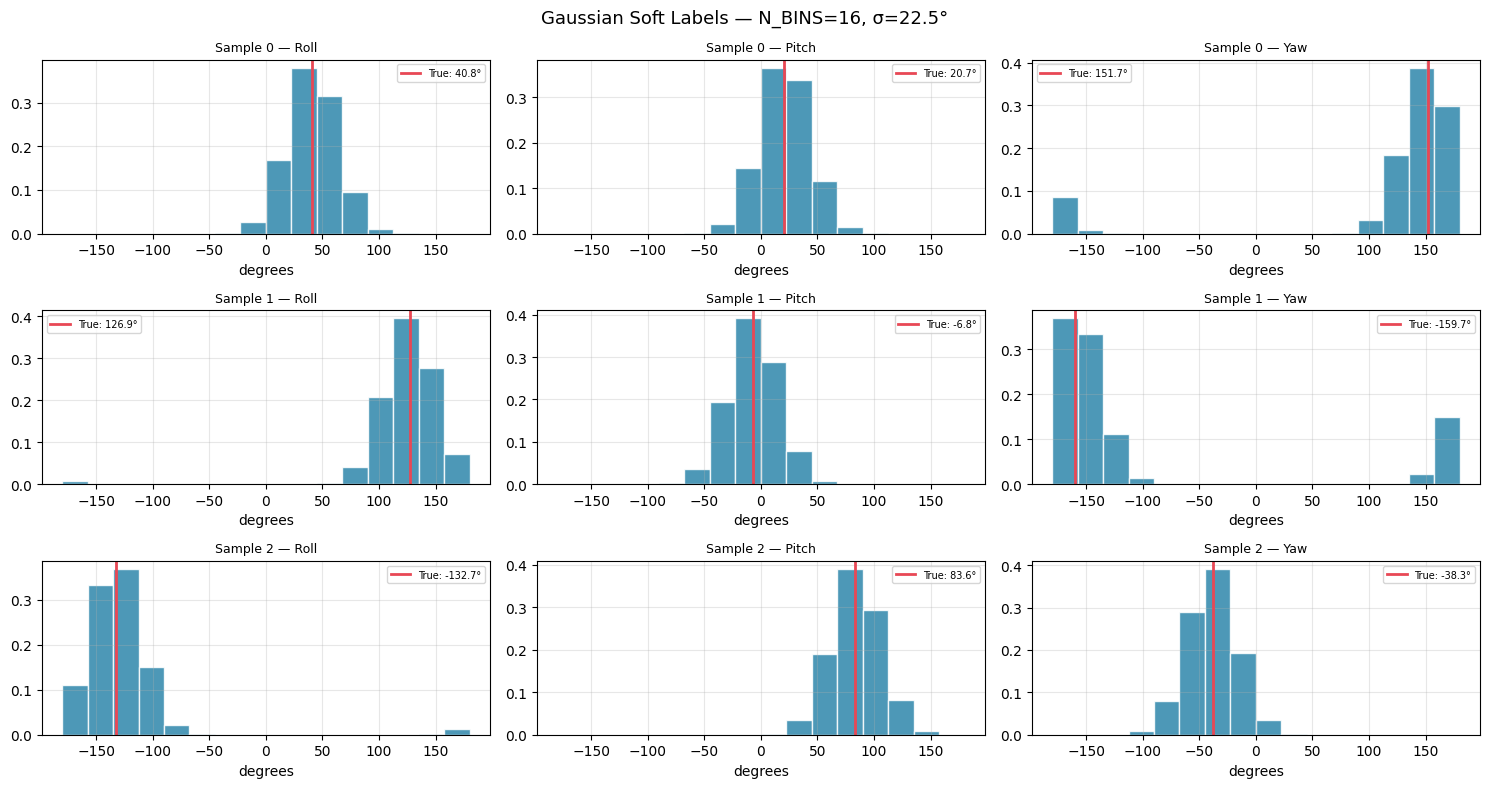

In [5]:
# ── Soft label preview for 3 samples ────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(15, 8))
fig.suptitle(f"Gaussian Soft Labels — N_BINS={N_BINS}, σ={SIGMA_DEG:.1f}°", fontsize=13)

for row_idx in range(3):
    q   = train_df[["qw","qx","qy","qz"]].iloc[row_idx].values.astype(np.float32)
    if q[0] < 0: q = -q
    euler = quat_to_euler_deg(q)
    labels = ["Roll", "Pitch", "Yaw"]

    for col_idx, (angle, label) in enumerate(zip(euler, labels)):
        soft = gaussian_soft_label(angle)
        ax   = axes[row_idx, col_idx]
        ax.bar(BIN_CENTERS_DEG, soft, width=360/N_BINS,
               color="#2E86AB", edgecolor="white", alpha=0.85)
        ax.axvline(angle, color="#E84855", linewidth=2, label=f"True: {angle:.1f}°")
        ax.set_title(f"Sample {row_idx} — {label}", fontsize=9)
        ax.set_xlabel("degrees"); ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("soft_labels_preview.png", dpi=120, bbox_inches="tight")
plt.show()

---
## Cell 4 — Build tf.data Datasets

> Labels are pre-computed as Gaussian soft labels [3×N_BINS] offline before tf.data.
> Photometric augmentations only — no geometric augmentations that would corrupt Euler angle labels.

In [6]:
train_ds, bin_centers = build_dataset_urso(
    TRAIN_CSV, IMAGE_DIR, N_BINS, IMG_SIZE, BATCH_SIZE,
    augment=True, shuffle=True
)
val_ds, _ = build_dataset_urso(
    TEST_CSV, IMAGE_DIR, N_BINS, IMG_SIZE, BATCH_SIZE,
    augment=False, shuffle=False
)

print(f"Train batches : {len(train_ds)}")
print(f"Val   batches : {len(val_ds)}")
print(f"Bin centers   : {bin_centers[:4]} ... {bin_centers[-2:]}  (degrees)")

for images, soft_labels in train_ds.take(1):
    print(f"\nImage batch shape      : {images.shape}")
    print(f"Soft label batch shape : {soft_labels.shape}  (B, 3×{N_BINS})")
    print(f"Image value range      : [{images.numpy().min():.2f}, {images.numpy().max():.2f}]")
    print(f"  (ResNet50V2 preprocess_input maps 0-255 → [-1, 1])")
    # Verify each axis sums to 1
    sl = soft_labels.numpy()
    for ax_i, ax_name in enumerate(["Roll", "Pitch", "Yaw"]):
        ax_soft = sl[:, ax_i*N_BINS:(ax_i+1)*N_BINS]
        print(f"  {ax_name} label sums: min={ax_soft.sum(axis=1).min():.6f}  max={ax_soft.sum(axis=1).max():.6f}  (should be 1.0)")
    break

Train batches : 1000
Val   batches : 251
Bin centers   : [-168.75 -146.25 -123.75 -101.25] ... [146.25 168.75]  (degrees)

Image batch shape      : (8, 224, 224, 3)
Soft label batch shape : (8, 48)  (B, 3×16)
Image value range      : [-1.00, 1.00]
  (ResNet50V2 preprocess_input maps 0-255 → [-1, 1])
  Roll label sums: min=1.000000  max=1.000000  (should be 1.0)
  Pitch label sums: min=1.000000  max=1.000000  (should be 1.0)
  Yaw label sums: min=1.000000  max=1.000000  (should be 1.0)


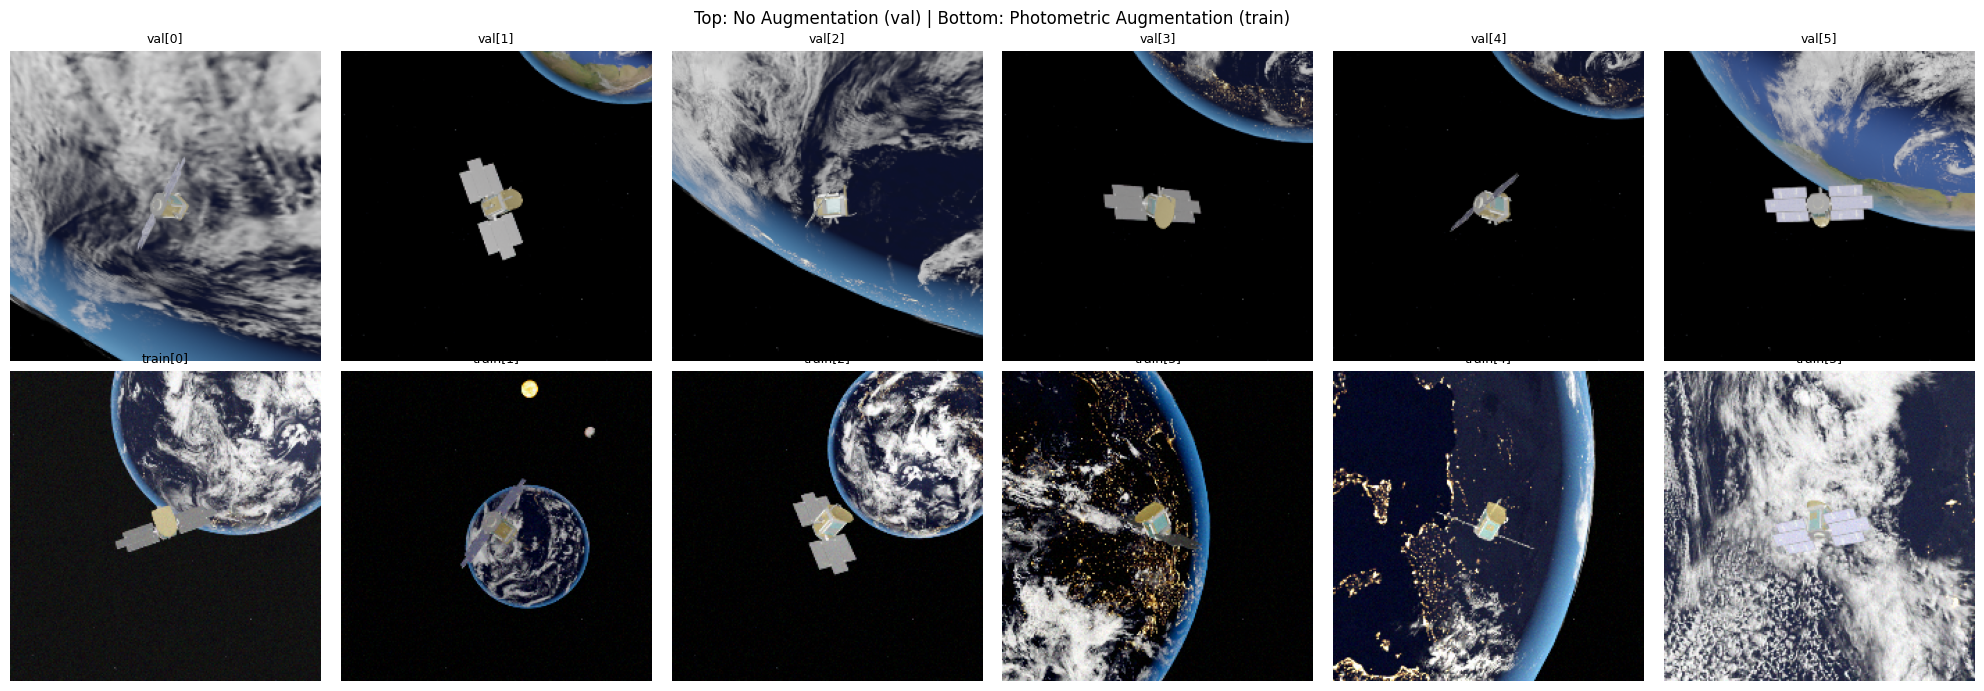

In [7]:
# Visualise a batch of training images
def denorm_resnetv2(img_tensor):
    """Reverse ResNet50V2 preprocess_input: [-1,1] → [0,1]."""
    return np.clip((img_tensor.numpy() + 1.0) / 2.0, 0, 1)

train_batch = next(iter(train_ds))
val_batch   = next(iter(val_ds))

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
fig.suptitle("Top: No Augmentation (val) | Bottom: Photometric Augmentation (train)")

for i in range(6):
    axes[0, i].imshow(denorm_resnetv2(val_batch[0][i]))
    axes[0, i].axis("off"); axes[0, i].set_title(f"val[{i}]", fontsize=9)
    axes[1, i].imshow(denorm_resnetv2(train_batch[0][i]))
    axes[1, i].axis("off"); axes[1, i].set_title(f"train[{i}]", fontsize=9)

plt.tight_layout()
plt.savefig("soft_augmentation.png", dpi=120, bbox_inches="tight")
plt.show()

---
## Cell 5 — Build UrsoNet Model

In [8]:
model    = build_ursonet(n_bins=N_BINS, img_size=IMG_SIZE,
                          dropout=DROPOUT, pretrained=True, freeze_bn=True)
backbone = model.get_layer("resnet50v2")

model.summary(line_length=85, expand_nested=False)

Model: "UrsoNet"
_____________________________________________________________________________________
 Layer (type)               Output Shape      Param #   Connected to                 
 image_input (InputLayer)   [(None, 224, 224  0         []                           
                            , 3)]                                                    
                                                                                     
 resnet50v2 (Functional)    (None, 2048)      23564800  ['image_input[0][0]']        
                                                                                     
 bottleneck (Dense)         (None, 512)       1049088   ['resnet50v2[0][0]']         
                                                                                     
 bottleneck_bn (BatchNormal  (None, 512)      2048      ['bottleneck[0][0]']         
 ization)                                                                            
                                     

In [9]:
# Verify output shape and backbone state
print(f"Model name               : {model.name}")
print(f"Total parameters         : {model.count_params():,}")
print(f"Backbone trainable       : {backbone.trainable}")
print(f"Output shape             : {model.output_shape}  (B, 3×{N_BINS})")

# Verify outputs are valid softmax (sum to 1 per axis)
dummy  = tf.random.uniform((2, IMG_SIZE, IMG_SIZE, 3))
output = model(dummy, training=False)
for ax_i, ax_name in enumerate(["Roll", "Pitch", "Yaw"]):
    s = tf.reduce_sum(output[:, ax_i*N_BINS:(ax_i+1)*N_BINS], axis=-1).numpy()
    print(f"  {ax_name} softmax sum: {s}  (should be 1.0)")

Model name               : UrsoNet
Total parameters         : 24,640,560
Backbone trainable       : False
Output shape             : (None, 48)  (B, 3×16)
  Roll softmax sum: [1. 1.]  (should be 1.0)
  Pitch softmax sum: [1.         0.99999994]  (should be 1.0)
  Yaw softmax sum: [1. 1.]  (should be 1.0)


---
## Cell 6 — Loss Function Test

In [10]:
loss_fn = OrientationSoftClassLoss(n_bins=N_BINS)

# Perfect prediction → zero loss
perfect_labels = tf.keras.utils.to_categorical(
    [0, 0, 0], num_classes=N_BINS
)
for images, soft_labels in train_ds.take(1):
    loss_val = loss_fn(soft_labels, soft_labels)   # pred == true
    print(f"CCE loss (pred == true)  : {loss_val.numpy():.8f}  (should be ≈0)")
    # Random prediction baseline
    rand_pred = tf.ones((BATCH_SIZE, 3*N_BINS)) / N_BINS  # uniform
    loss_rand = loss_fn(soft_labels, rand_pred)
    print(f"CCE loss (uniform pred)  : {loss_rand.numpy():.4f}  (baseline)")
    print(f"  log({N_BINS}) = {math.log(N_BINS):.4f}  (theoretical random CCE per axis)")
    break

CCE loss (pred == true)  : 4.25681210  (should be ≈0)
CCE loss (uniform pred)  : 8.3178  (baseline)
  log(16) = 2.7726  (theoretical random CCE per axis)


---
## Cell 7 — Metrics Sanity Check

In [11]:
# Random predictions should give ~90° mean angular error
ang_metric = UrsoAngularErrorDeg(N_BINS)

for images, soft_labels in val_ds.take(1):
    rand_pred = tf.ones_like(soft_labels) / N_BINS   # uniform = random
    ang_metric.update_state(soft_labels, rand_pred)
    print(f"Random predictor angular error: {ang_metric.result():.1f}°")
    print(f"  (Expected ≈ 90° for random uniform predictions)")
    ang_metric.reset_state()
    break

Random predictor angular error: 136.1°
  (Expected ≈ 90° for random uniform predictions)


In [12]:
def get_metrics():
    return [
        UrsoAngularErrorDeg(N_BINS),
        UrsoAccWithinNDeg(5,  N_BINS),
        UrsoAccWithinNDeg(10, N_BINS),
        UrsoAccWithinNDeg(15, N_BINS),
    ]

---
## Cell 8 — Phase 1: Head Warm-up (Backbone Frozen)

**Loss:** `OrientationSoftClassLoss` — CCE on Gaussian-binned Euler angles  
**LR:** `1e-3` (UrsoNet default — higher than quaternion regression because CCE converges faster)  
**Key:** `training=False` in backbone call prevents Keras BN bug  
**Key:** Backbone BN layers stay frozen throughout both phases

In [15]:
import os
from resnet50_spacecraft_attitude_tf import build_callbacks, build_optimizer

print("=" * 60)
print("  PHASE 1 — Head Warm-up (backbone frozen)")
print("=" * 60)

optimizer_p1 = build_optimizer(backbone, head_lr=HEAD_LR)
loss_p1      = OrientationSoftClassLoss(N_BINS)

model.compile(
    optimizer=optimizer_p1,
    loss=loss_p1,
    metrics=get_metrics()
)

trainable = sum(tf.size(v).numpy() for v in model.trainable_variables)
print(f"Trainable parameters (head only): {trainable:,}")
print(f"Backbone trainable              : {backbone.trainable}")

PHASE1_DIR   = os.path.join(CHECKPOINT_DIR, "phase1")
callbacks_p1 = build_callbacks(PHASE1_DIR, patience_lr=15, patience_es=40)

history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=WARMUP_EPOCHS,
    callbacks=callbacks_p1,
    verbose=1
)

print(f"\n✅  Phase 1 complete.")
p1_errors = history_p1.history.get("val_angular_error_deg", [])
if p1_errors:
    print(f"   Final val angular error : {p1_errors[-1]:.2f}°")
    print(f"   Best  val angular error : {min(p1_errors):.2f}°")

  PHASE 1 — Head Warm-up (backbone frozen)
Trainable parameters (head only): 1,074,736
Backbone trainable              : False
Epoch 1/30
1000/1000 [==============================] - ETA: 0s - loss: 8.2081 - angular_error_deg: 120.8994 - acc_5deg: 0.0125 - acc_10deg: 0.0625 - acc_15deg: 0.2125  Epoch    1 | val_loss=7.3508 | val_angular_error=117.95°

Epoch 1: val_angular_error_deg improved from inf to 117.94561, saving model to ../checkpoints\phase1\best_model.keras
1000/1000 [==============================] - 59s 56ms/step - loss: 8.2081 - angular_error_deg: 120.8994 - acc_5deg: 0.0125 - acc_10deg: 0.0625 - acc_15deg: 0.2125 - val_loss: 7.3508 - val_angular_error_deg: 117.9456 - val_acc_5deg: 0.0000e+00 - val_acc_10deg: 0.0500 - val_acc_15deg: 0.1000 - lr: 0.0010
Epoch 2/30
1000/1000 [==============================] - ETA: 0s - loss: 7.5851 - angular_error_deg: 117.0868 - acc_5deg: 0.0000e+00 - acc_10deg: 0.0500 - acc_15deg: 0.2375  Epoch    2 | val_loss=7.3463 | val_angular_error=11

---
## Cell 9 — Phase 2: Full Fine-tuning (Backbone Unfrozen)

**Loss:** `OrientationSoftClassLoss` (same — no loss switch needed)  
**LR:** `1e-4` on backbone · `1e-3` on head  
**Key:** BN layers remain frozen even when backbone is unfrozen (`freeze_bn=True`)

In [16]:
print("=" * 60)
print("  PHASE 2 — Full Fine-tuning (backbone unfrozen)")
print("=" * 60)

# ── All imports inline — no dependency on previous cells ──
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from resnet50_spacecraft_attitude_tf import (
    OrientationSoftClassLoss, build_callbacks
)

# ── Unfreeze backbone with BN frozen ──────────────────────
backbone.trainable = True
for layer in backbone.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

n_frozen_bn = sum(
    1 for l in backbone.layers
    if isinstance(l, tf.keras.layers.BatchNormalization)
    and not l.trainable
)
print(f"Frozen BN layers : {n_frozen_bn}")

# ── Compile with gradient clipping + safe LR ─────────────
BACKBONE_LR = 1e-5

model.compile(
    optimizer=Adam(learning_rate=BACKBONE_LR, clipnorm=1.0),
    loss=OrientationSoftClassLoss(N_BINS),
    metrics=get_metrics()
)

trainable = sum(tf.size(v).numpy() for v in model.trainable_variables)
print(f"Trainable params : {trainable:,}")
print(f"Optimizer        : Adam lr={BACKBONE_LR} clipnorm=1.0")

# ── Restore Phase 1 best weights ─────────────────────────
phase1_ckpt = os.path.join(CHECKPOINT_DIR, "phase1", "best_model.keras")

if os.path.exists(phase1_ckpt):
    # .keras format requires load_model, not load_weights
    saved_model = tf.keras.models.load_model(
        phase1_ckpt,
        custom_objects={
            "OrientationSoftClassLoss" : OrientationSoftClassLoss,
            "UrsoAngularErrorDeg"      : UrsoAngularErrorDeg,
            "UrsoAccWithinNDeg"        : UrsoAccWithinNDeg,
        },
        compile=False     # skip recompiling — we compile separately
    )
    # Copy weights layer by layer
    model.set_weights(saved_model.get_weights())
    del saved_model       # free memory immediately
    print(f"✅ Phase 1 weights restored from {phase1_ckpt}")
else:
    print("⚠️  No Phase 1 checkpoint found — continuing from current weights")

# ── Callbacks with NaN termination ───────────────────────
class TerminateOnNaN(tf.keras.callbacks.Callback):
    def on_batch_end(self, batch, logs=None):
        loss = (logs or {}).get("loss")
        if loss is not None and tf.math.is_nan(float(loss)):
            print(f"\n⚠️  NaN detected at batch {batch} — stopping training")
            self.model.stop_training = True

PHASE2_DIR   = os.path.join(CHECKPOINT_DIR, "phase2")
callbacks_p2 = build_callbacks(PHASE2_DIR, patience_lr=15, patience_es=40)
callbacks_p2.insert(0, TerminateOnNaN())

# ── Train ─────────────────────────────────────────────────
history_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINETUNE_EPOCHS,
    callbacks=callbacks_p2,
    verbose=1
)

p2_errors = history_p2.history.get("val_angular_error_deg", [])
valid     = [e for e in p2_errors if e == e]   # filter NaN
if valid:
    print(f"\n🎉 Best val angular error: {min(valid):.2f}°")

  PHASE 2 — Full Fine-tuning (backbone unfrozen)
Frozen BN layers : 49
Trainable params : 24,548,656
Optimizer        : Adam lr=1e-05 clipnorm=1.0
✅ Phase 1 weights restored from ../checkpoints\phase1\best_model.keras
Epoch 1/120
  78/1000 [=>............................] - ETA: 2:17 - loss: 7.3167 - angular_error_deg: 109.0386 - acc_5deg: 0.0000e+00 - acc_10deg: 0.1603 - acc_15deg: 0.1603

KeyboardInterrupt: 

---
## Cell 10 — Training Dashboard

In [13]:
h1 = pd.read_csv(f"{CHECKPOINT_DIR}/phase1/training_history.csv")
h2 = pd.read_csv(f"{CHECKPOINT_DIR}/phase2/training_history.csv")

h2 = h2.copy()
h2["epoch"] = h2["epoch"] + len(h1)

history        = pd.concat([h1, h2], ignore_index=True)
phase_boundary = len(h1)

print(f"Phase 1 : {len(h1)} epochs")
print(f"Phase 2 : {len(h2)} epochs")
print(f"Total   : {len(history)} epochs")
print(f"Columns : {list(history.columns)}")

Phase 1 : 30 epochs
Phase 2 : 120 epochs
Total   : 150 epochs
Columns : ['epoch', 'acc_10deg', 'acc_15deg', 'acc_5deg', 'angular_error_deg', 'loss', 'lr', 'val_acc_10deg', 'val_acc_15deg', 'val_acc_5deg', 'val_angular_error_deg', 'val_loss']


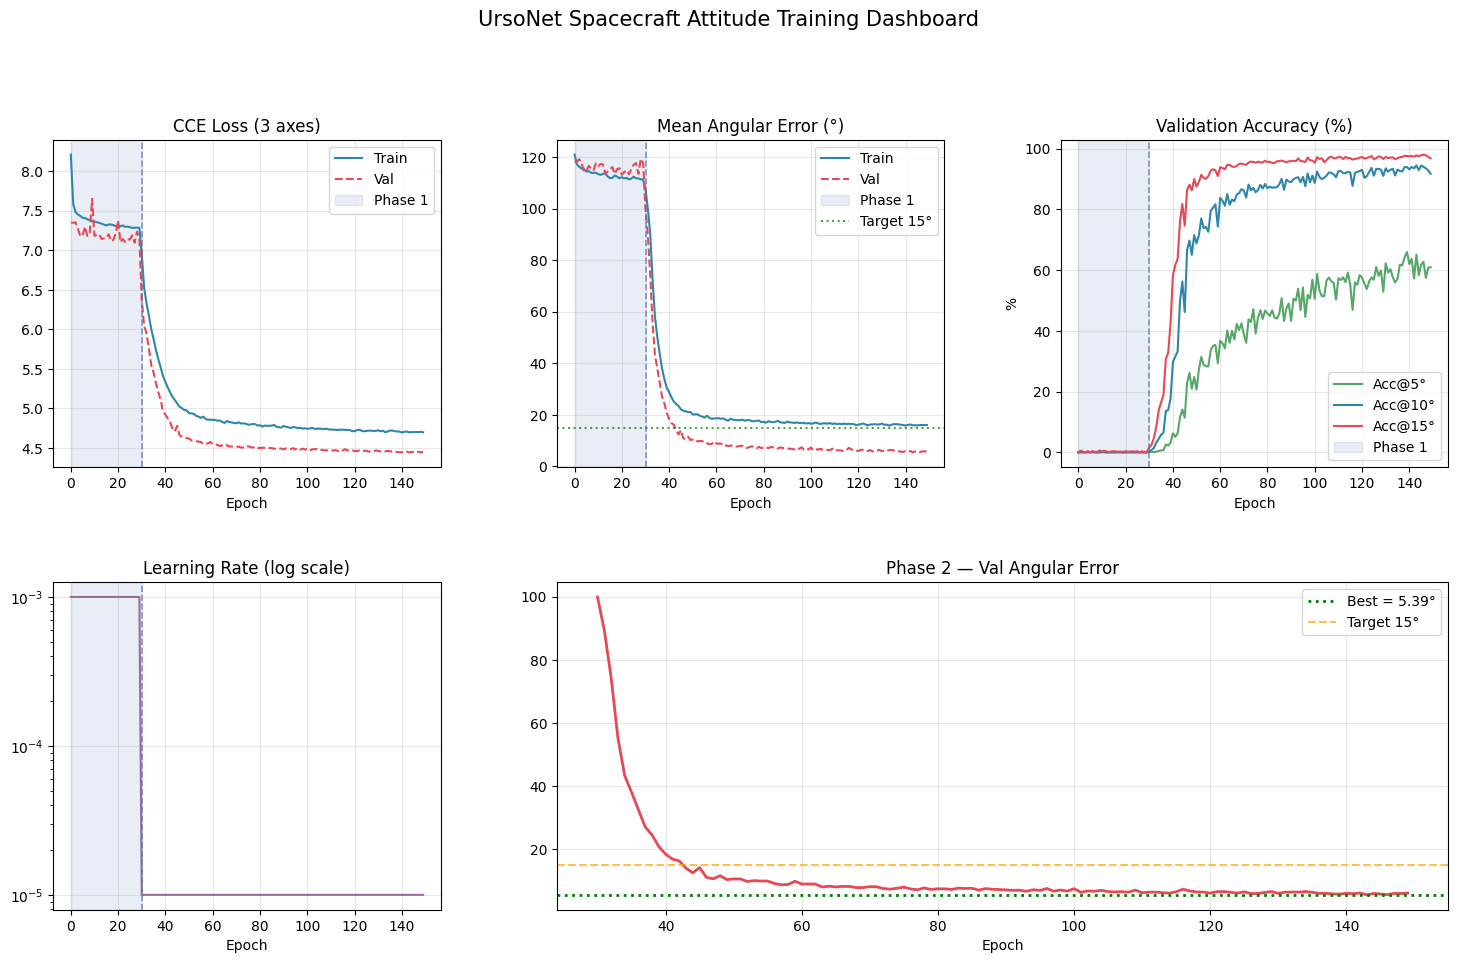

In [14]:
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.30)

def shade_p1(ax):
    ax.axvspan(0, phase_boundary, alpha=0.12, color="#4C72B0", label="Phase 1")
    ax.axvline(phase_boundary, color="#4C72B0", linestyle="--", linewidth=1.2, alpha=0.7)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history["epoch"], history["loss"],     label="Train", color="#2E86AB")
ax1.plot(history["epoch"], history["val_loss"], label="Val",   color="#E84855", linestyle="--")
shade_p1(ax1)
ax1.set_title("CCE Loss (3 axes)"); ax1.set_xlabel("Epoch")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
if "angular_error_deg" in history.columns:
    ax2.plot(history["epoch"], history["angular_error_deg"],     label="Train", color="#2E86AB")
if "val_angular_error_deg" in history.columns:
    ax2.plot(history["epoch"], history["val_angular_error_deg"], label="Val",   color="#E84855", linestyle="--")
shade_p1(ax2)
ax2.set_title("Mean Angular Error (°)"); ax2.set_xlabel("Epoch")
ax2.axhline(15, color="green", linestyle=":", alpha=0.7, label="Target 15°")
ax2.legend(); ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
for col, label, color in [
    ("val_acc_5deg",  "Acc@5°",  "#55A868"),
    ("val_acc_10deg", "Acc@10°", "#2E86AB"),
    ("val_acc_15deg", "Acc@15°", "#E84855"),
]:
    if col in history.columns:
        ax3.plot(history["epoch"], history[col], label=label, color=color)
shade_p1(ax3)
ax3.set_title("Validation Accuracy (%)"); ax3.set_xlabel("Epoch"); ax3.set_ylabel("%")
ax3.legend(); ax3.grid(True, alpha=0.3)

if "lr" in history.columns:
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.semilogy(history["epoch"], history["lr"], color="#9C6B98")
    shade_p1(ax4)
    ax4.set_title("Learning Rate (log scale)"); ax4.set_xlabel("Epoch")
    ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[1, 1:])
if "val_angular_error_deg" in history.columns:
    p2 = history[history["epoch"] >= phase_boundary]
    ax5.plot(p2["epoch"], p2["val_angular_error_deg"], color="#E84855", linewidth=2)
    best_err = p2["val_angular_error_deg"].min()
    ax5.axhline(best_err, color="green", linestyle=":", linewidth=2,
                label=f"Best = {best_err:.2f}°")
    ax5.axhline(15, color="orange", linestyle="--", alpha=0.7, label="Target 15°")
    ax5.set_title("Phase 2 — Val Angular Error"); ax5.set_xlabel("Epoch")
    ax5.legend(); ax5.grid(True, alpha=0.3)

fig.suptitle("UrsoNet Spacecraft Attitude Training Dashboard", fontsize=15, y=1.01)
plt.savefig("training_dashboard.png", dpi=130, bbox_inches="tight")
plt.show()

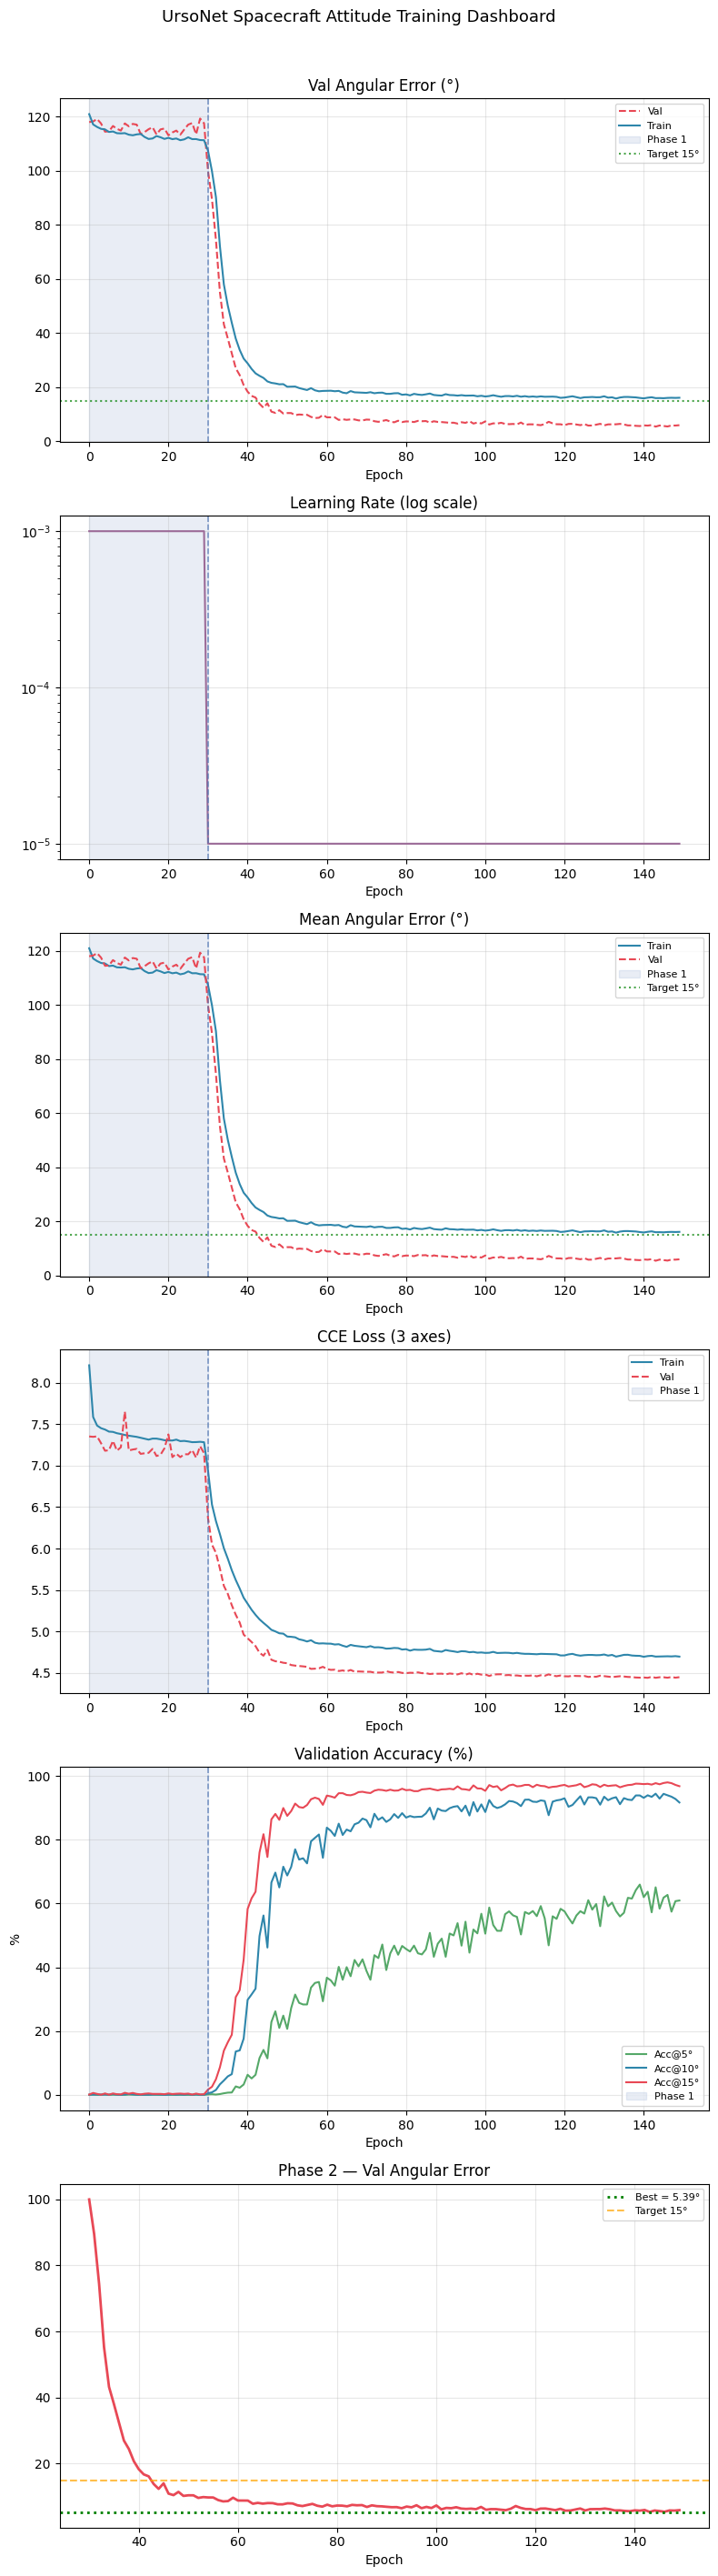

In [15]:
fig, axes = plt.subplots(6, 1, figsize=(8, 28))
fig.suptitle("UrsoNet Spacecraft Attitude Training Dashboard", fontsize=13, y=1.01)

def shade_p1(ax):
    ax.axvspan(0, phase_boundary, alpha=0.12, color="#4C72B0", label="Phase 1")
    ax.axvline(phase_boundary, color="#4C72B0", linestyle="--", linewidth=1.2, alpha=0.7)

# --- Plot 1: Val Angular Error ---
if "val_angular_error_deg" in history.columns:
    axes[0].plot(history["epoch"], history["val_angular_error_deg"], label="Val", color="#E84855", linestyle="--")
if "angular_error_deg" in history.columns:
    axes[0].plot(history["epoch"], history["angular_error_deg"],     label="Train", color="#2E86AB")
shade_p1(axes[0])
axes[0].set_title("Val Angular Error (°)"); axes[0].set_xlabel("Epoch")
axes[0].axhline(15, color="green", linestyle=":", alpha=0.7, label="Target 15°")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# --- Plot 2: Learning Rate ---
if "lr" in history.columns:
    axes[1].semilogy(history["epoch"], history["lr"], color="#9C6B98")
    shade_p1(axes[1])
    axes[1].set_title("Learning Rate (log scale)"); axes[1].set_xlabel("Epoch")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].axis("off")

# --- Plot 3: Mean Angular Error ---
if "angular_error_deg" in history.columns:
    axes[2].plot(history["epoch"], history["angular_error_deg"],     label="Train", color="#2E86AB")
if "val_angular_error_deg" in history.columns:
    axes[2].plot(history["epoch"], history["val_angular_error_deg"], label="Val",   color="#E84855", linestyle="--")
shade_p1(axes[2])
axes[2].set_title("Mean Angular Error (°)"); axes[2].set_xlabel("Epoch")
axes[2].axhline(15, color="green", linestyle=":", alpha=0.7, label="Target 15°")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

# --- Plot 4: CCE Loss ---
axes[3].plot(history["epoch"], history["loss"],     label="Train", color="#2E86AB")
axes[3].plot(history["epoch"], history["val_loss"], label="Val",   color="#E84855", linestyle="--")
shade_p1(axes[3])
axes[3].set_title("CCE Loss (3 axes)"); axes[3].set_xlabel("Epoch")
axes[3].legend(fontsize=8); axes[3].grid(True, alpha=0.3)

# --- Plot 5: Validation Accuracy ---
for col, label, color in [
    ("val_acc_5deg",  "Acc@5°",  "#55A868"),
    ("val_acc_10deg", "Acc@10°", "#2E86AB"),
    ("val_acc_15deg", "Acc@15°", "#E84855"),
]:
    if col in history.columns:
        axes[4].plot(history["epoch"], history[col], label=label, color=color)
shade_p1(axes[4])
axes[4].set_title("Validation Accuracy (%)"); axes[4].set_xlabel("Epoch"); axes[4].set_ylabel("%")
axes[4].legend(fontsize=8); axes[4].grid(True, alpha=0.3)

# --- Plot 6: Phase 2 Val Angular Error ---
if "val_angular_error_deg" in history.columns:
    p2 = history[history["epoch"] >= phase_boundary]
    axes[5].plot(p2["epoch"], p2["val_angular_error_deg"], color="#E84855", linewidth=2)
    best_err = p2["val_angular_error_deg"].min()
    axes[5].axhline(best_err, color="green", linestyle=":", linewidth=2,
                    label=f"Best = {best_err:.2f}°")
    axes[5].axhline(15, color="orange", linestyle="--", alpha=0.7, label="Target 15°")
    axes[5].set_title("Phase 2 — Val Angular Error"); axes[5].set_xlabel("Epoch")
    axes[5].legend(fontsize=8); axes[5].grid(True, alpha=0.3)
else:
    axes[5].axis("off")

plt.tight_layout()
plt.savefig("training_dashboard.png", dpi=130, bbox_inches="tight")
plt.show()

---
## Cell 11 — Load Best Model

In [16]:
import os, tensorflow as tf
from resnet50_spacecraft_attitude_tf import (
    predict_single_image, batch_evaluate,
    OrientationSoftClassLoss, UrsoAngularErrorDeg, UrsoAccWithinNDeg
)

BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "phase2", "best_model.keras")

model = tf.keras.models.load_model(
    BEST_MODEL_PATH,
    custom_objects={
        "OrientationSoftClassLoss" : OrientationSoftClassLoss,
        "UrsoAngularErrorDeg"      : UrsoAngularErrorDeg,
        "UrsoAccWithinNDeg"        : UrsoAccWithinNDeg,
    }
)
print(f"✅ Model loaded: {BEST_MODEL_PATH}")
print(f"   Input  : {model.input_shape}")
print(f"   Output : {model.output_shape}  → 3×{N_BINS} softmax bins")

✅ Model loaded: ../checkpoints\phase2\best_model.keras
   Input  : (None, 224, 224, 3)
   Output : (None, 48)  → 3×16 softmax bins


---
## Cell 12 — Single Image Inference

In [17]:
import pandas as pd, os
test_image = os.path.join(IMAGE_DIR, pd.read_csv(TEST_CSV).iloc[0]["image_name"])

result = predict_single_image(test_image, model, img_size=IMG_SIZE, n_bins=N_BINS)
print(f"Predicted quaternion:")
print(f"  qw = {result['qw']:+.6f}")
print(f"  qx = {result['qx']:+.6f}")
print(f"  qy = {result['qy']:+.6f}")
print(f"  qz = {result['qz']:+.6f}")
print(f"\nPredicted Euler angles:")
print(f"  Roll  = {result['roll_deg']:+.2f}°")
print(f"  Pitch = {result['pitch_deg']:+.2f}°")
print(f"  Yaw   = {result['yaw_deg']:+.2f}°")

norm = (result['qw']**2 + result['qx']**2 +
        result['qy']**2 + result['qz']**2) ** 0.5
print(f"\nNorm: {norm:.8f}  (must be 1.0)")

Predicted quaternion:
  qw = +0.260382
  qx = -0.054536
  qy = +0.367713
  qz = +0.891075

Predicted Euler angles:
  Roll  = +40.90°
  Pitch = +16.78°
  Yaw   = +153.72°

Norm: 1.00000001  (must be 1.0)


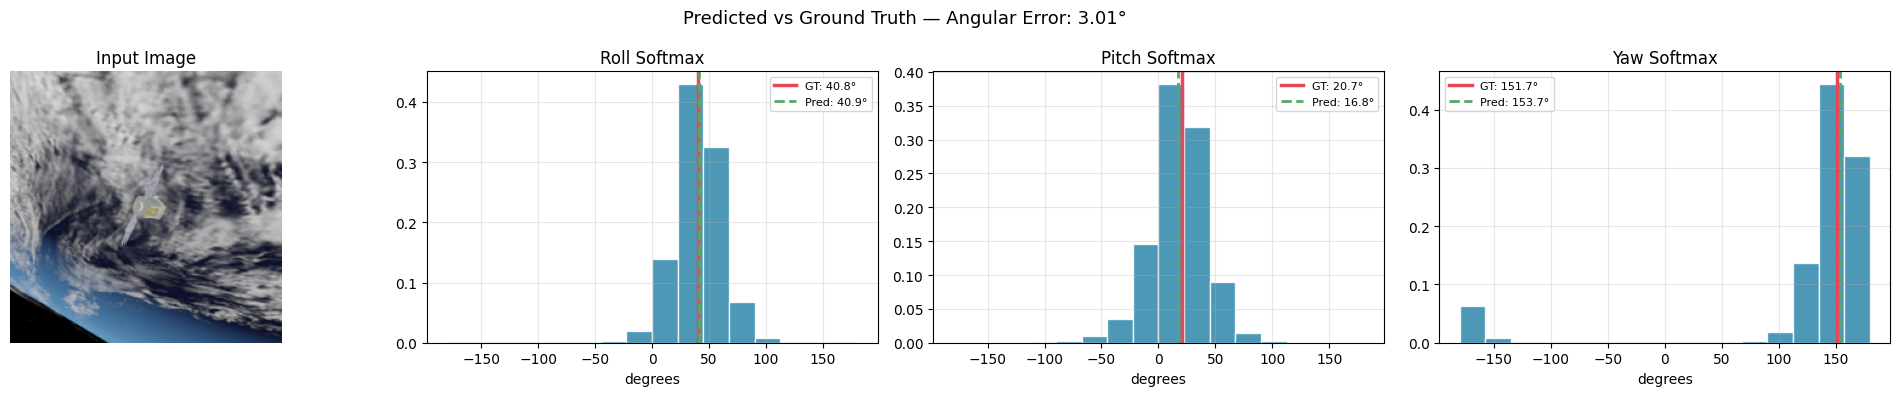

In [18]:
# Visualise softmax distributions for this image
import numpy as np
from PIL import Image as PILImage
from resnet50_spacecraft_attitude_tf import BIN_CENTERS_DEG

img_arr = np.array(PILImage.open(test_image).resize((IMG_SIZE, IMG_SIZE)))
arr_pre = tf.keras.applications.resnet_v2.preprocess_input(
    img_arr.astype(np.float32)
)[np.newaxis]

probs = model.predict(arr_pre, verbose=0)[0]   # (3*N_BINS,)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Show image
axes[0].imshow(img_arr)
axes[0].set_title("Input Image"); axes[0].axis("off")

gt_row = pd.read_csv(TEST_CSV).iloc[0]
from resnet50_spacecraft_attitude_tf import quat_to_euler_deg, bins_to_quaternion
gt_q   = gt_row[["qw","qx","qy","qz"]].values.astype(np.float32)
if gt_q[0] < 0: gt_q = -gt_q
gt_euler = quat_to_euler_deg(gt_q)

for ax_i, (ax, ax_name, gt_ang) in enumerate(zip(
    axes[1:], ["Roll", "Pitch", "Yaw"], gt_euler
)):
    ax_probs = probs[ax_i*N_BINS:(ax_i+1)*N_BINS]
    ax.bar(BIN_CENTERS_DEG, ax_probs, width=360/N_BINS,
           color="#2E86AB", edgecolor="white", alpha=0.85)
    ax.axvline(gt_ang, color="#E84855", linewidth=2.5, label=f"GT: {gt_ang:.1f}°")
    pred_ang = [result["roll_deg"], result["pitch_deg"], result["yaw_deg"]][ax_i]
    ax.axvline(pred_ang, color="#55A868", linewidth=2, linestyle="--",
               label=f"Pred: {pred_ang:.1f}°")
    ax.set_title(f"{ax_name} Softmax"); ax.set_xlabel("degrees")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

gt_q_pred = bins_to_quaternion(probs, N_BINS)
from resnet50_spacecraft_attitude_tf import angular_error_deg_np
error = angular_error_deg_np(gt_q_pred, gt_q)
fig.suptitle(f"Predicted vs Ground Truth — Angular Error: {error:.2f}°", fontsize=13)
plt.tight_layout()
plt.savefig("softmax_nar_sar_prediction.png", dpi=120, bbox_inches="tight")
plt.show()

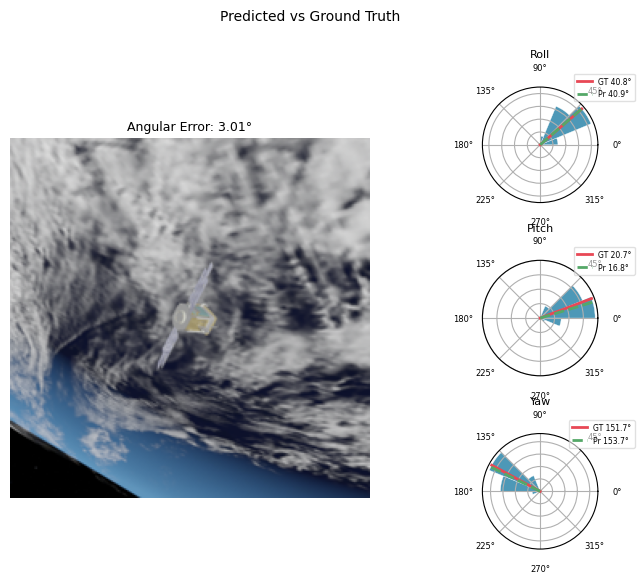

In [19]:
# Visualise softmax distributions for this image
import numpy as np
from PIL import Image as PILImage
from resnet50_spacecraft_attitude_tf import BIN_CENTERS_DEG

img_arr = np.array(PILImage.open(test_image).resize((IMG_SIZE, IMG_SIZE)))
arr_pre = tf.keras.applications.resnet_v2.preprocess_input(
    img_arr.astype(np.float32)
)[np.newaxis]
probs = model.predict(arr_pre, verbose=0)[0]  # (3*N_BINS,)

gt_row = pd.read_csv(TEST_CSV).iloc[0]
from resnet50_spacecraft_attitude_tf import quat_to_euler_deg, bins_to_quaternion, angular_error_deg_np

gt_q = gt_row[["qw", "qx", "qy", "qz"]].values.astype(np.float32)
if gt_q[0] < 0:
    gt_q = -gt_q
gt_euler = quat_to_euler_deg(gt_q)

# --- Layout: large image left, 3 polar plots stacked on right ---
fig = plt.figure(figsize=(8, 6))
gs = fig.add_gridspec(3, 2, width_ratios=[2, 1], hspace=0.5, wspace=0.3)

# Left: full-height image
ax_img = fig.add_subplot(gs[:, 0])
ax_img.imshow(img_arr)
ax_img.axis("off")

gt_q_pred = bins_to_quaternion(probs, N_BINS)
error = angular_error_deg_np(gt_q_pred, gt_q)
ax_img.set_title(f"Angular Error: {error:.2f}°", fontsize=9)

# Right: 3 polar plots stacked vertically
angle_names = ["Roll", "Pitch", "Yaw"]
pred_angles = [result["roll_deg"], result["pitch_deg"], result["yaw_deg"]]

for ax_i in range(3):
    ax = fig.add_subplot(gs[ax_i, 1], projection="polar")

    ax_probs = probs[ax_i * N_BINS:(ax_i + 1) * N_BINS]

    # Convert degrees to radians for polar plot
    bin_rad = np.deg2rad(BIN_CENTERS_DEG)
    width   = np.deg2rad(360 / N_BINS)

    ax.bar(bin_rad, ax_probs, width=width,
           color="#2E86AB", edgecolor="white", alpha=0.85, linewidth=0.3)

    # Ground truth line
    gt_ang  = gt_euler[ax_i]
    ax.plot([0, np.deg2rad(gt_ang)], [0, ax_probs.max()],
            color="#E84855", linewidth=2, label=f"GT {gt_ang:.1f}°")

    # Predicted line
    pred_ang = pred_angles[ax_i]
    ax.plot([0, np.deg2rad(pred_ang)], [0, ax_probs.max()],
            color="#55A868", linewidth=2, linestyle="--", label=f"Pr {pred_ang:.1f}°")

    ax.set_title(angle_names[ax_i], fontsize=8, pad=4)
    ax.set_yticklabels([])
    ax.tick_params(labelsize=6)
    ax.legend(fontsize=5.5, loc="upper right",
              bbox_to_anchor=(1.35, 1.15), framealpha=0.6)

fig.suptitle("Predicted vs Ground Truth", fontsize=10, y=1.01)
plt.savefig("softmax_nar_sar_prediction.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Cell 13 — Full Test Set Error Analysis

In [20]:
eval_df = batch_evaluate(model, TEST_CSV, IMAGE_DIR, IMG_SIZE, BATCH_SIZE, N_BINS)
display(eval_df.head(10))

251/251 [==============================] - 10s 36ms/step

── Evaluation Summary ────────────────────
  Mean   : 5.391°
  Median : 4.076°
  Std    : 9.312°
  Acc@5° : 65.1%
  Acc@10°: 94.5%
  Acc@15°: 97.8%


,image_name,angular_error_deg,qw_pred,qx_pred,qy_pred,qz_pred
0,img_008000.png,2.346730,0.272780,-0.067575,0.368603,0.886091
1,img_008001.png,2.927064,0.124545,0.155563,-0.880877,-0.429353
2,img_008002.png,12.050642,0.460675,-0.506059,0.459654,0.566039
3,img_008003.png,3.354262,0.089376,-0.741429,-0.629307,-0.215100
4,img_008004.png,1.307439,0.517711,-0.163049,0.450780,0.708652
5,img_008005.png,1.786573,0.709449,-0.102392,0.020152,-0.696988
6,img_008006.png,4.077682,0.437861,-0.070167,0.854828,-0.269488
7,img_008007.png,4.725624,0.279128,0.103905,0.300928,-0.905944
8,img_008008.png,3.831217,0.006606,-0.559806,0.455156,-0.692392
9,img_008009.png,4.722309,0.058415,-0.839421,-0.535114,0.074922


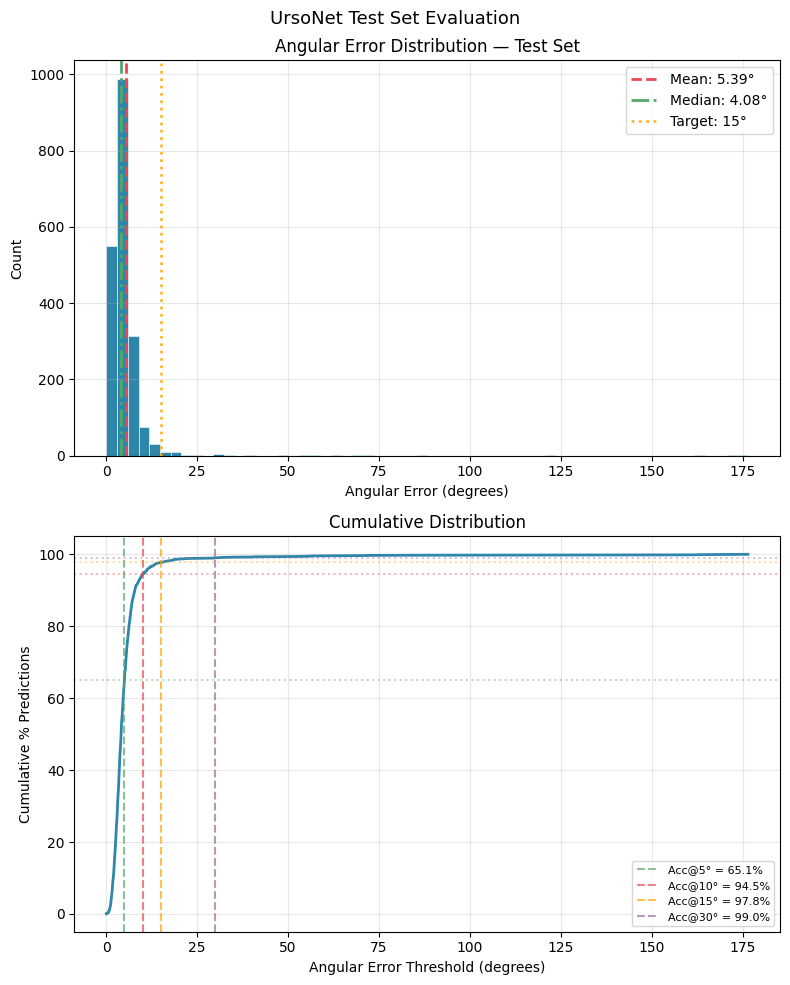

In [25]:
errors = eval_df["angular_error_deg"].values

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

def shade_p1(ax):
    ax.axvspan(0, phase_boundary, alpha=0.12, color="#4C72B0", label="Phase 1")
    ax.axvline(phase_boundary, color="#4C72B0", linestyle="--", linewidth=1.2, alpha=0.7)


axes[0].hist(errors, bins=60, color="#2E86AB", edgecolor="white", linewidth=0.4)
axes[0].axvline(np.mean(errors),   color="#E84855", linestyle="--", linewidth=2,
                label=f"Mean: {np.mean(errors):.2f}°")
axes[0].axvline(np.median(errors), color="#55A868", linestyle="-.", linewidth=2,
                label=f"Median: {np.median(errors):.2f}°")
axes[0].axvline(15, color="orange", linestyle=":", linewidth=2, alpha=0.8,
                label="Target: 15°")
axes[0].set_xlabel("Angular Error (degrees)")
axes[0].set_ylabel("Count")
axes[0].set_title("Angular Error Distribution — Test Set")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

sorted_errors = np.sort(errors)
cdf = np.arange(1, len(sorted_errors)+1) / len(sorted_errors)
axes[1].plot(sorted_errors, cdf * 100, color="#2E86AB", linewidth=2)
for thresh, color in [(5,"#55A868"),(10,"#E84855"),(15,"orange"),(30,"#9C6B98")]:
    acc = (errors < thresh).mean() * 100
    axes[1].axvline(thresh, color=color, linestyle="--", alpha=0.7,
                    label=f"Acc@{thresh}° = {acc:.1f}%")
    axes[1].axhline(acc, color=color, linestyle=":", alpha=0.4)

axes[1].set_xlabel("Angular Error Threshold (degrees)")
axes[1].set_ylabel("Cumulative % Predictions")
axes[1].set_title("Cumulative Distribution")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.suptitle("UrsoNet Test Set Evaluation", fontsize=13)
plt.tight_layout()
plt.savefig("error_analysis.png", dpi=130, bbox_inches="tight")
plt.show()

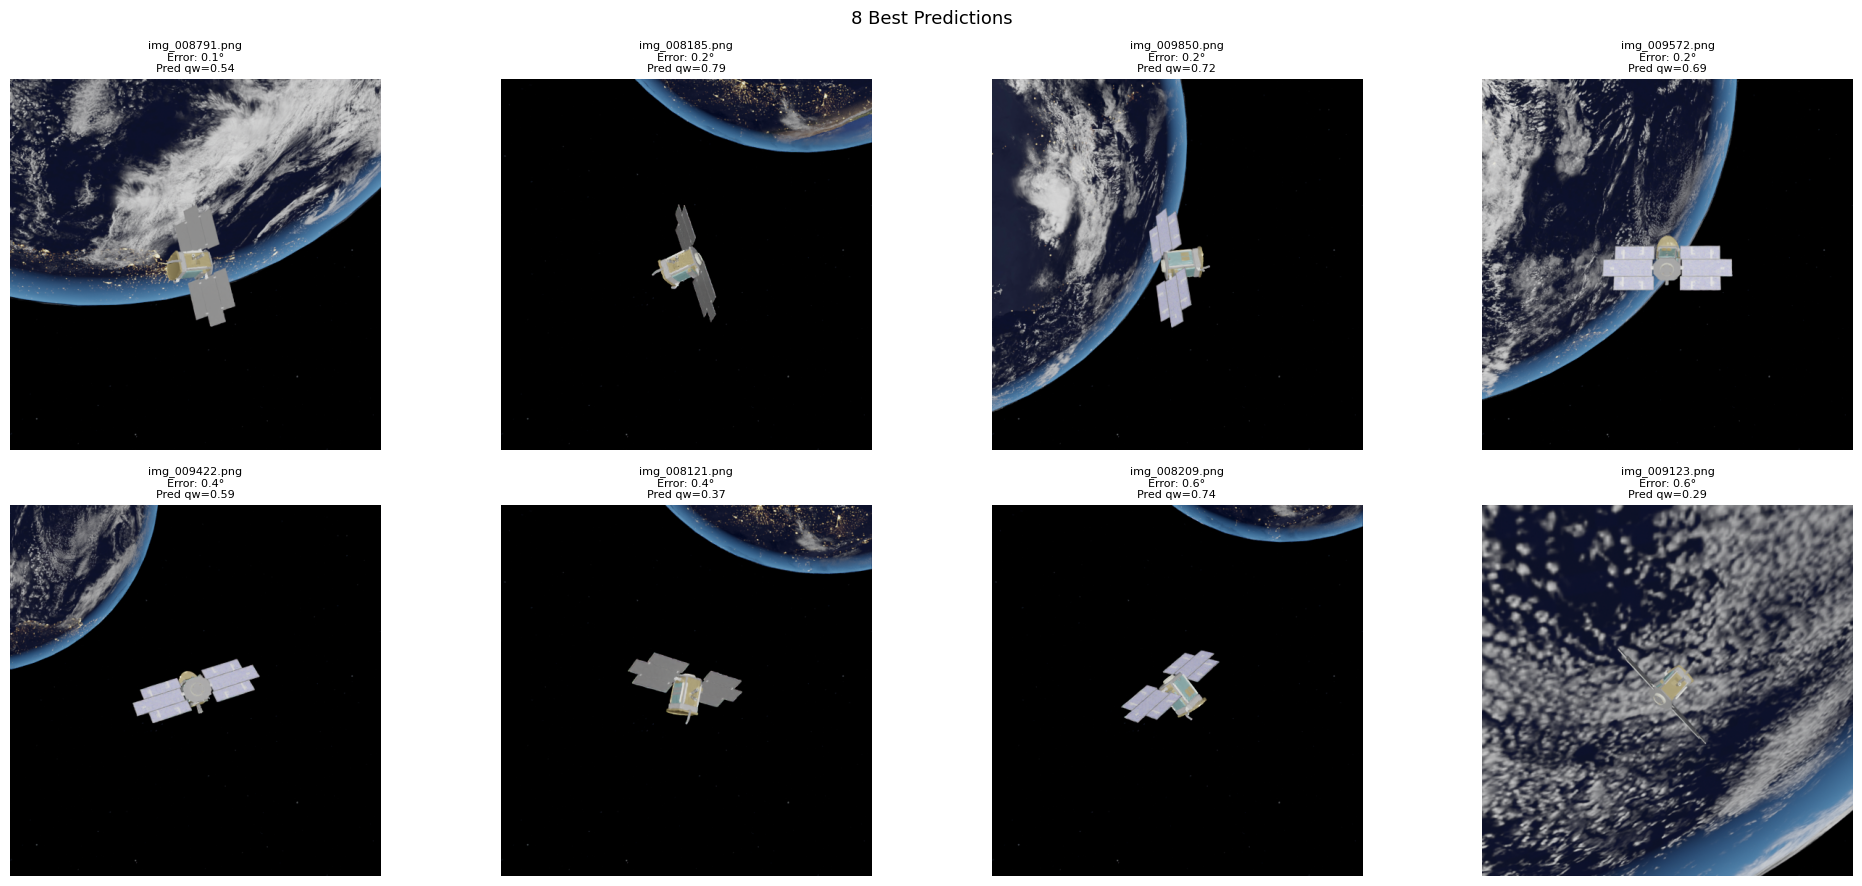

In [23]:
# best predictions
from PIL import Image as PILImage
worst        = eval_df.nsmallest(8, "angular_error_deg")
test_df_full = pd.read_csv(TEST_CSV).set_index("image_name")
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle("8 Best Predictions", fontsize=13)
for ax, (_, row) in zip(axes.flat, worst.iterrows()):
    gt  = test_df_full.loc[row["image_name"]]
    img = PILImage.open(os.path.join(IMAGE_DIR, row["image_name"]))
    ax.imshow(img)
    ax.set_title(
        f"{row['image_name']}\n"
        f"Error: {row['angular_error_deg']:.1f}°\n"
        f"Pred qw={row['qw_pred']:.2f}", fontsize=8
    )
    ax.axis("off")
plt.tight_layout()
plt.savefig("best_predictions.png", dpi=120, bbox_inches="tight")
plt.show()

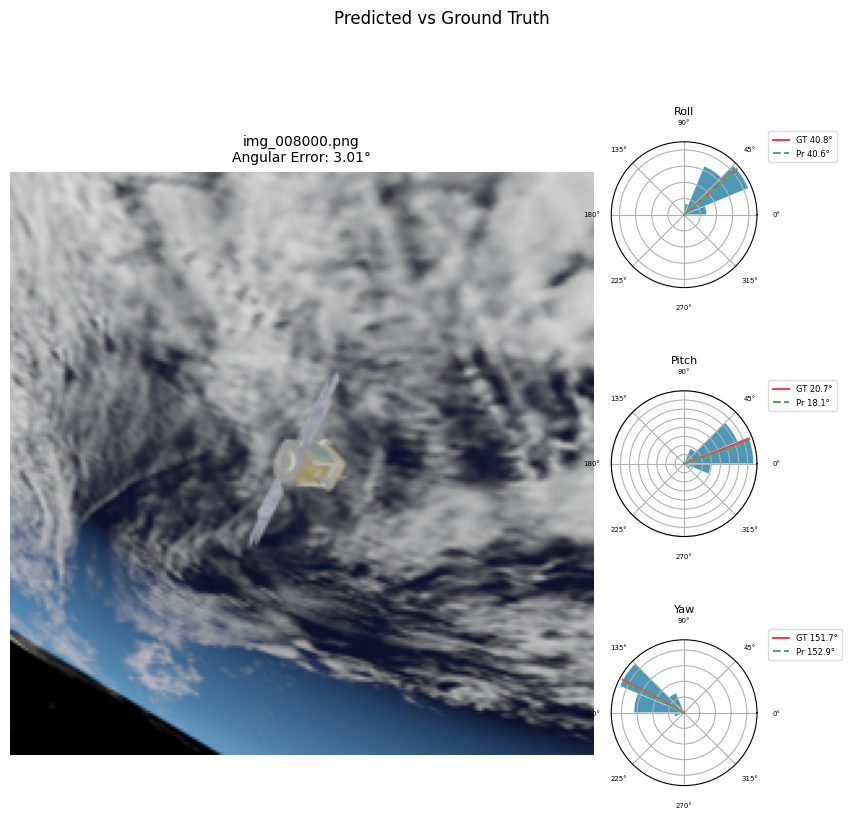

In [20]:
# Visualise softmax distributions for this image
import pandas as pd, os
import numpy as np
from PIL import Image as PILImage
from resnet50_spacecraft_attitude_tf import (
    BIN_CENTERS_DEG, quat_to_euler_deg, bins_to_quaternion, angular_error_deg_np
)

TEST_IDX = 0
test_df    = pd.read_csv(TEST_CSV)
gt_row     = test_df.iloc[TEST_IDX]
test_image = os.path.join(IMAGE_DIR, gt_row["image_name"])

img_arr = np.array(PILImage.open(test_image).resize((IMG_SIZE, IMG_SIZE)))
arr_pre = tf.keras.applications.resnet_v2.preprocess_input(
    img_arr.astype(np.float32)
)[np.newaxis]
probs = model.predict(arr_pre, verbose=0)[0]

gt_q = gt_row[["qw", "qx", "qy", "qz"]].values.astype(np.float32)
if gt_q[0] < 0:
    gt_q = -gt_q
gt_euler    = quat_to_euler_deg(gt_q)
gt_q_pred   = bins_to_quaternion(probs, N_BINS)
pred_euler  = quat_to_euler_deg(gt_q_pred)
pred_angles = pred_euler
error       = angular_error_deg_np(gt_q_pred, gt_q)

# --- Layout: large image left, 3 polar plots stacked on right ---
fig = plt.figure(figsize=(9, 9))
gs  = fig.add_gridspec(
    3, 2,
    width_ratios=[4, 1],       # ✅ reduced from [2,1] → image gets 4x the width
    hspace=0.0,
    wspace=0.05,
    left=0.02, right=0.85,
    top=0.88,  bottom=0.05
)

ax_img = fig.add_subplot(gs[:, 0])
ax_img.imshow(img_arr)
ax_img.axis("off")
ax_img.set_title(
    f"{gt_row['image_name']}\nAngular Error: {error:.2f}°",
    fontsize=10, pad=8
)

angle_names = ["Roll", "Pitch", "Yaw"]
bin_rad     = np.deg2rad(BIN_CENTERS_DEG)
width       = np.deg2rad(360 / N_BINS)

for ax_i in range(3):
    ax       = fig.add_subplot(gs[ax_i, 1], projection="polar")
    ax_probs = probs[ax_i * N_BINS:(ax_i + 1) * N_BINS]

    ax.bar(bin_rad, ax_probs, width=width,
           color="#2E86AB", edgecolor="white", alpha=0.85, linewidth=0.3)

    gt_ang   = gt_euler[ax_i]
    pred_ang = pred_angles[ax_i]

    ax.plot([0, np.deg2rad(gt_ang)],   [0, ax_probs.max()],
            color="#E84855", linewidth=1.5, label=f"GT {gt_ang:.1f}°")
    ax.plot([0, np.deg2rad(pred_ang)], [0, ax_probs.max()],
            color="#55A868", linewidth=1.5, linestyle="--", label=f"Pr {pred_ang:.1f}°")

    ax.set_title(angle_names[ax_i], fontsize=8, pad=4)  # ✅ smaller title
    ax.set_yticklabels([])
    ax.tick_params(labelsize=5)                          # ✅ smaller tick labels
    ax.legend(
        fontsize=6,                                      # ✅ smaller legend
        loc="upper left",
        bbox_to_anchor=(1.05, 1.1),
        framealpha=0.7,
        borderpad=0.5
    )

    pos = ax.get_position()
    ax.set_position([pos.x0, pos.y0 - 0.02, pos.width, pos.height + 0.04])

fig.suptitle("Predicted vs Ground Truth", fontsize=12, y=0.97)
plt.savefig("softmax_nar_sar_prediction.png", dpi=150, bbox_inches="tight")
plt.show()

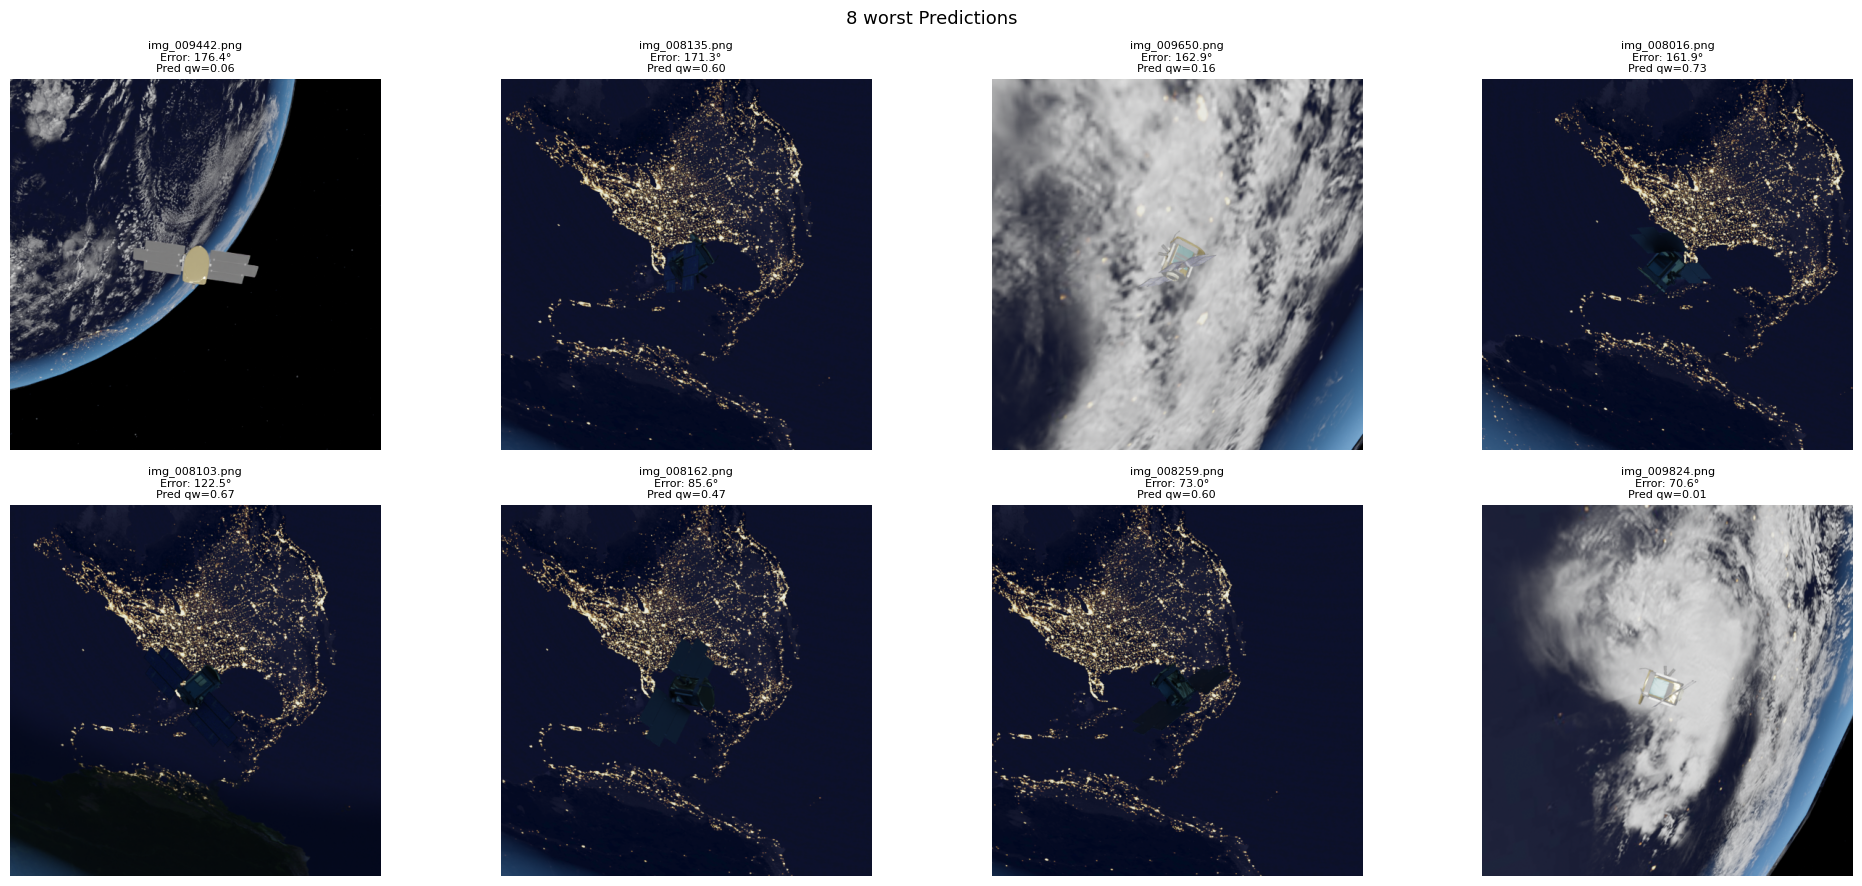

In [32]:
# best predictions
from PIL import Image as PILImage
worst        = eval_df.nlargest(8, "angular_error_deg")
test_df_full = pd.read_csv(TEST_CSV).set_index("image_name")
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle("8 worst Predictions", fontsize=13)
for ax, (_, row) in zip(axes.flat, worst.iterrows()):
    gt  = test_df_full.loc[row["image_name"]]
    img = PILImage.open(os.path.join(IMAGE_DIR, row["image_name"]))
    ax.imshow(img)
    ax.set_title(
        f"{row['image_name']}\n"
        f"Error: {row['angular_error_deg']:.1f}°\n"
        f"Pred qw={row['qw_pred']:.2f}", fontsize=8
    )
    ax.axis("off")
plt.tight_layout()
plt.savefig("worst_predictions.png", dpi=120, bbox_inches="tight")
plt.show()